# Day 05 — Python → SQLite

Every project day from Day 06 on runs against a local `.sqlite` file instead of a MySQL server. Rather than meeting SQLite for the first time on an unfamiliar project dataset, this notebook first rebuilds the already-familiar `parch_and_posey` as a local SQLite file, verifies the migration, then re-runs a full sweep through every Day 01-04 concept against the copy — plus safe parameter binding and some visualizations, since turning a query result into a chart is exactly the kind of thing Python adds that a plain SQL client can't.

**Before you start:** run `day05_python_mysql.ipynb` first, or at least its setup cell — this notebook reads from the same live MySQL connection to build the SQLite copy.

## Setup — reconnect to MySQL (the source data)

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import pandas as pd

load_dotenv()

mysql_url = URL.create(
    "mysql+mysqlconnector",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", "3306")),
    database=os.getenv("DB_NAME"),
)
mysql_engine = create_engine(mysql_url, connect_args={"use_pure": True})

MySQL still needs SQLAlchemy here — `URL.create()` for safe credential encoding, and `use_pure` for the driver bug from `day05_python_mysql.ipynb`. That's a MySQL-specific need. SQLite is a different story, starting below.

## Section 1 — Migrating parch_and_posey into a local SQLite file

**Business question:** a teammate without MySQL installed still needs to work with this data — hand them a single portable file instead.

The destination side uses Python's built-in `sqlite3` module directly — no SQLAlchemy, no extra install. `pandas.to_sql`/`read_sql` both accept a raw `sqlite3.Connection` just as happily as a SQLAlchemy engine.

In [2]:
import sqlite3

sqlite_conn = sqlite3.connect("parch_and_posey.sqlite")

TABLES = ["region", "sales_reps", "accounts", "orders", "web_events"]
mysql_counts, sqlite_counts = {}, {}

for table in TABLES:
    df = pd.read_sql(text(f"SELECT * FROM {table}"), mysql_engine)
    mysql_counts[table] = len(df)
    df.to_sql(table, sqlite_conn, index=False, if_exists="replace")

sqlite_conn.commit()

`parch_and_posey.sqlite` is generated here, not committed to git — regenerate it any time by re-running this cell, same reasoning as never committing `.env`.

**Verify the migration** — don't just assume it worked, check row-for-row that every table landed correctly.

In [3]:
for table in TABLES:
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", sqlite_conn)["n"][0]
    sqlite_counts[table] = int(count)

comparison = pd.DataFrame({"mysql_rows": mysql_counts, "sqlite_rows": sqlite_counts})
comparison["match"] = comparison["mysql_rows"] == comparison["sqlite_rows"]
comparison

,mysql_rows,sqlite_rows,match
region,4,4,True
sales_reps,50,50,True
accounts,351,351,True
orders,6912,6912,True
web_events,9073,9073,True


## Section 2 — The cursor, once more, on SQLite

Same DB-API pattern from `day05_python_mysql.ipynb`, different driver underneath: connect, get a cursor, `execute()`, `fetchall()`. `sqlite_conn` from the migration step above already **is** a connection, so this reuses it directly — no new import, no new connect call.

In [4]:
cursor = sqlite_conn.cursor()
cursor.execute("SELECT name FROM region ORDER BY name")

for row in cursor.fetchall():
    print(row)

cursor.close()

('Midwest',)
('Northeast',)
('Southeast',)
('West',)


In [5]:
%load_ext sql

## Section 3 — Two ways to run %%sql against SQLite

**Option 1 — through SQLAlchemy**, the same pattern the MySQL notebook uses:

In [6]:
sqlalchemy_demo_engine = create_engine("sqlite:///parch_and_posey.sqlite")
%sql sqlalchemy_demo_engine --alias sqlite_via_sqlalchemy

In [7]:
%%sql
SELECT COUNT(*) AS num_accounts FROM accounts;

Running query in 'sqlite_via_sqlalchemy'

num_accounts
351


**Option 2 — jupysql directly, with a bare connection string, no SQLAlchemy import at all:**

In [8]:
%sql sqlite:///parch_and_posey.sqlite --alias sqlite_pp

Connecting and switching to connection 'sqlite_pp'

In [9]:
%%sql
SELECT COUNT(*) AS num_accounts FROM accounts;

Running query in 'sqlite_pp'

num_accounts
351


Same result, no `create_engine` needed — jupysql builds whatever it needs internally from the connection string alone. This is also the exact pattern the Kaggle-based project notebooks (Days 06-09) already use. **From here on, this notebook uses Option 2** — `sqlite_pp` is now the active connection for every `%%sql` cell below.

### Day 01 review

**SELECT + LIMIT/OFFSET** — Marketing wants the NEXT 5 accounts alphabetically, after the first 5 (page 2 of a list).

In [10]:
%%sql
SELECT name FROM accounts ORDER BY name LIMIT 5 OFFSET 5;

Running query in 'sqlite_pp'

name
AT&T
AbbVie
Abbott Laboratories
Advance Auto Parts
Aetna


**DISTINCT** — How many distinct marketing channels appear in web_events?

In [11]:
%%sql
SELECT DISTINCT channel FROM web_events;

Running query in 'sqlite_pp'

channel
direct
facebook
organic
adwords
twitter
banner


**ORDER BY + COUNT** — How many total orders has the company ever received?

In [12]:
%%sql
SELECT COUNT(*) AS total_orders FROM orders;

Running query in 'sqlite_pp'

total_orders
6912


### Day 02 review

**WHERE + comparison operators** — Which orders sold for more than $5,000?

In [13]:
%%sql
SELECT id, account_id, total_amt_usd FROM orders WHERE total_amt_usd > 5000;

Running query in 'sqlite_pp'

id,account_id,total_amt_usd
24,1031,7474.32
129,1141,26055.46
176,1181,11390.06
214,1221,12664.72
234,1231,13522.55
262,1261,5905.77
290,1281,5338.72
297,1281,6925.43
301,1281,5342.55
320,1281,29699.28


**AND / OR** — Which orders had over 100 standard-paper units AND at least one poster?

In [14]:
%%sql
SELECT id, standard_qty, poster_qty FROM orders WHERE standard_qty > 100 AND poster_qty > 0;

Running query in 'sqlite_pp'

id,standard_qty,poster_qty
1,123,24
2,190,57
5,108,28
6,103,46
7,101,92
12,124,39
13,104,44
15,127,44
16,123,19
20,483,21


**BETWEEN** — Which orders were placed during 2016?

In [15]:
%%sql
SELECT id, occurred_at FROM orders WHERE occurred_at BETWEEN '2016-01-01' AND '2016-12-31';

Running query in 'sqlite_pp'

id,occurred_at
4,2016-01-02 01:18:24
5,2016-02-01 19:27:27
6,2016-03-02 15:29:32
7,2016-04-01 11:20:18
8,2016-05-01 15:55:51
9,2016-05-31 21:22:48
10,2016-06-30 12:32:05
11,2016-07-30 03:26:30
12,2016-08-28 07:13:39
13,2016-09-26 23:28:25


**IN** — Which regions are Northeast or West?

In [16]:
%%sql
SELECT * FROM region WHERE name IN ('Northeast', 'West');

Running query in 'sqlite_pp'

id,name
1,Northeast
4,West


**NULL checks** — Are there any orders with a missing (NULL) gloss_qty?

In [17]:
%%sql
SELECT COUNT(*) AS null_gloss_orders FROM orders WHERE gloss_qty IS NULL;

Running query in 'sqlite_pp'

null_gloss_orders
0


**LIKE** — Which accounts have a name starting with 'A'?

In [18]:
%%sql
SELECT name FROM accounts WHERE name LIKE 'A%' LIMIT 5;

Running query in 'sqlite_pp'

name
Apple
AT&T
AmerisourceBergen
Amazon.com
Anthem


**GROUP BY + aggregates** — What's the total spend per account, biggest first?

In [19]:
%%sql
SELECT account_id, SUM(total_amt_usd) AS total_spend FROM orders GROUP BY account_id ORDER BY total_spend DESC LIMIT 5;

Running query in 'sqlite_pp'

account_id,total_spend
4211,382873.3
4151,345618.59
1301,326819.48
1871,300694.79
4111,293861.14


**DATE functions** — How many orders were placed each year? *(SQLite syntax differs slightly — see below.)*

In [20]:
%%sql
SELECT STRFTIME('%Y', occurred_at) AS yr, COUNT(*) AS num_orders FROM orders GROUP BY yr ORDER BY yr;

Running query in 'sqlite_pp'

yr,num_orders
2013,99
2014,1306
2015,1725
2016,3757
2017,25


### Day 03 review

**INNER JOIN** — Combine every order with the account that placed it.

In [21]:
%%sql
SELECT o.id, a.name FROM orders o JOIN accounts a ON o.account_id = a.id LIMIT 5;

Running query in 'sqlite_pp'

id,name
1,Walmart
2,Walmart
3,Walmart
4,Walmart
5,Walmart


**Multi-table JOIN** — Trace an order back to the sales rep who owns that account.

In [22]:
%%sql
SELECT o.id, a.name AS account, s.name AS rep FROM orders o JOIN accounts a ON o.account_id = a.id JOIN sales_reps s ON a.sales_rep_id = s.id LIMIT 5;

Running query in 'sqlite_pp'

id,account,rep
1,Walmart,Samuel Racine
2,Walmart,Samuel Racine
3,Walmart,Samuel Racine
4,Walmart,Samuel Racine
5,Walmart,Samuel Racine


**JOIN + GROUP BY** — Total revenue per sales rep.

In [23]:
%%sql
SELECT s.name, SUM(o.total_amt_usd) AS total_sales FROM orders o JOIN accounts a ON o.account_id = a.id JOIN sales_reps s ON a.sales_rep_id = s.id GROUP BY s.name ORDER BY total_sales DESC LIMIT 5;

Running query in 'sqlite_pp'

name,total_sales
Earlie Schleusner,1098137.72
Tia Amato,1010690.6
Vernita Plump,934212.93
Georgianna Chisholm,886244.12
Arica Stoltzfus,810353.34


**JOIN + HAVING** — Which sales reps manage more than 5 accounts?

In [24]:
%%sql
SELECT s.id, s.name, COUNT(*) AS num_accounts FROM accounts a JOIN sales_reps s ON s.id = a.sales_rep_id GROUP BY s.id, s.name HAVING COUNT(*) > 5 LIMIT 5;

Running query in 'sqlite_pp'

id,name,num_accounts
321500,Samuel Racine,6
321510,Eugena Esser,6
321520,Michel Averette,7
321560,Elba Felder,6
321580,Sibyl Lauria,6


**LEFT JOIN + anti-join** — Which accounts have NEVER placed an order?

In [25]:
%%sql
SELECT a.id, a.name FROM accounts a LEFT JOIN orders o ON a.id = o.account_id WHERE o.id IS NULL;

Running query in 'sqlite_pp'

id,name
1731,Goldman Sachs Group


**FULL JOIN via UNION** — Every order/account pairing, matched or not (MySQL has no FULL JOIN).

In [26]:
%%sql
SELECT * FROM orders LEFT JOIN accounts ON orders.account_id = accounts.id UNION SELECT * FROM orders RIGHT JOIN accounts ON orders.account_id = accounts.id LIMIT 5;

Running query in 'sqlite_pp'

id,account_id,occurred_at,standard_qty,gloss_qty,poster_qty,total,standard_amt_usd,gloss_amt_usd,poster_amt_usd,total_amt_usd,id_1,name,website,latitude,longitude,primary_poc,sales_rep_id
None,None,None,None,None,None,None,None,None,None,None,1731,Goldman Sachs Group,www.gs.com,40.75744399,-73.96730918,Loris Manfredi,321690
1,1001,2015-10-06 17:31:14,123,22,24,169,613.77,164.78,194.88,973.43,1001,Walmart,www.walmart.com,40.23849561,-75.10329704,Tamara Tuma,321500
2,1001,2015-11-05 03:34:33,190,41,57,288,948.1,307.09,462.84,1718.03,1001,Walmart,www.walmart.com,40.23849561,-75.10329704,Tamara Tuma,321500
3,1001,2015-12-04 04:21:55,85,47,0,132,424.15,352.03,0.0,776.18,1001,Walmart,www.walmart.com,40.23849561,-75.10329704,Tamara Tuma,321500
4,1001,2016-01-02 01:18:24,144,32,0,176,718.56,239.68,0.0,958.24,1001,Walmart,www.walmart.com,40.23849561,-75.10329704,Tamara Tuma,321500


**CASE** — Tag every order 'Large' (over $2,000) or 'Small'.

In [27]:
%%sql
SELECT id, total_amt_usd, CASE WHEN total_amt_usd > 2000 THEN 'Large' ELSE 'Small' END AS size_tag FROM orders LIMIT 5;

Running query in 'sqlite_pp'

id,total_amt_usd,size_tag
1,973.43,Small
2,1718.03,Small
3,776.18,Small
4,958.24,Small
5,983.49,Small


**CASE + GROUP BY** — Bucket every account into a top/middle/low lifetime-value tier.

In [28]:
%%sql
SELECT a.name, SUM(o.total_amt_usd) AS total_spend, CASE WHEN SUM(o.total_amt_usd) > 200000 THEN 'top' WHEN SUM(o.total_amt_usd) > 100000 THEN 'middle' ELSE 'low' END AS tier FROM orders o JOIN accounts a ON o.account_id = a.id GROUP BY a.name ORDER BY total_spend DESC LIMIT 5;

Running query in 'sqlite_pp'

name,total_spend,tier
EOG Resources,382873.3,top
Mosaic,345618.59,top
IBM,326819.48,top
General Dynamics,300694.79,top
Republic Services,293861.14,top


**CASE + HAVING** — Which sales reps fall specifically in the 'under $5k' sales bracket?

In [29]:
%%sql
SELECT s.name, SUM(o.total_amt_usd) AS total_sales FROM accounts a JOIN orders o ON a.id = o.account_id JOIN sales_reps s ON s.id = a.sales_rep_id GROUP BY s.name HAVING SUM(o.total_amt_usd) BETWEEN 1 AND 5000;

Running query in 'sqlite_pp'

name,total_sales


**String functions** — Clean a padded name, and build an email from an account's point of contact. *(SQLite syntax differs slightly — see below.)*

In [30]:
%%sql
SELECT TRIM('   Alexander Freberg   ') AS trimmed, CONCAT(LOWER(SUBSTR('Alexander', 1, 4)), '@example.com') AS sample_email;

Running query in 'sqlite_pp'

trimmed,sample_email
Alexander Freberg,alex@example.com


**COALESCE / IFNULL** — Fill in a friendly label wherever a computed bucket is NULL. *(SQLite syntax differs slightly — see below.)*

In [31]:
%%sql
SELECT COALESCE(NULL, 'unclassified') AS label;

Running query in 'sqlite_pp'

label
unclassified


### Day 04 review

**Scalar subquery** — Which orders sold for more than the company-wide average?

In [32]:
%%sql
SELECT id, total_amt_usd FROM orders WHERE total_amt_usd > (SELECT AVG(total_amt_usd) FROM orders) LIMIT 5;

Running query in 'sqlite_pp'

id,total_amt_usd
24,7474.32
37,4393.44
48,3405.62
88,3585.33
129,26055.46


**Row subquery** — Each account's single most recent web event.

In [33]:
%%sql
SELECT account_id, occurred_at, channel FROM web_events WHERE (account_id, occurred_at) IN (SELECT account_id, MAX(occurred_at) FROM web_events GROUP BY account_id) ORDER BY account_id LIMIT 5;

Running query in 'sqlite_pp'

account_id,occurred_at,channel
1001,2016-12-24 05:35:14,direct
1011,2016-12-21 16:14:29,adwords
1021,2017-01-01 02:56:41,organic
1031,2016-12-25 16:59:27,facebook
1041,2016-12-28 16:32:24,direct


**Derived table** — Average number of daily web events, per channel.

In [34]:
%%sql
SELECT channel, AVG(events) AS avg_events_per_day FROM (SELECT channel, DATE(occurred_at) AS day, COUNT(*) AS events FROM web_events GROUP BY day, channel) AS daily GROUP BY channel;

Running query in 'sqlite_pp'

channel,avg_events_per_day
adwords,1.5701906412478337
banner,1.2899728997289972
direct,4.896487985212569
facebook,1.5983471074380164
organic,1.6672504378283712
twitter,1.3166666666666667


**CTE** — Same average-events question, written as a CTE instead.

In [35]:
%%sql
WITH daily AS (SELECT channel, DATE(occurred_at) AS day, COUNT(*) AS events FROM web_events GROUP BY day, channel) SELECT channel, AVG(events) AS avg_events_per_day FROM daily GROUP BY channel;

Running query in 'sqlite_pp'

channel,avg_events_per_day
adwords,1.5701906412478337
banner,1.2899728997289972
direct,4.896487985212569
facebook,1.5983471074380164
organic,1.6672504378283712
twitter,1.3166666666666667


**Chained CTEs** — Which accounts spend above the company-wide average account spend?

In [36]:
%%sql
WITH account_totals AS (SELECT a.id, a.name, SUM(o.total_amt_usd) AS total_spend FROM orders o JOIN accounts a ON o.account_id = a.id GROUP BY a.id, a.name), avg_total AS (SELECT AVG(total_spend) AS avg_spend FROM account_totals) SELECT * FROM account_totals WHERE total_spend > (SELECT avg_spend FROM avg_total) LIMIT 5;

Running query in 'sqlite_pp'

id,name,total_spend
1001,Walmart,124014.87
1081,Ford Motor,154811.43
1121,Verizon,115376.17
1181,Walgreens Boots Alliance,130153.59
1221,J.P. Morgan Chase,94684.25


**Temporary table** — Materialize the top customer once, then query it twice. *(SQLite syntax differs slightly — see below.)*

In [37]:
%%sql
CREATE TEMPORARY TABLE top_customer_demo AS SELECT a.id, a.name, SUM(o.total_amt_usd) AS total_sales FROM orders o JOIN accounts a ON o.account_id = a.id GROUP BY a.id, a.name ORDER BY total_sales DESC LIMIT 1;

Running query in 'sqlite_pp'

++
||
++
++

**View** — A 'top 10 customers' leaderboard, saved for repeated use.

In [38]:
%%sql
DROP VIEW IF EXISTS top10_customers_demo;

CREATE VIEW top10_customers_demo AS SELECT a.id, a.name, SUM(o.total_amt_usd) AS total_sales FROM orders o JOIN accounts a ON o.account_id = a.id GROUP BY a.id, a.name ORDER BY total_sales DESC LIMIT 10;

Running query in 'sqlite_pp'

++
||
++
++

**Window function: running total** — Running total of standard-paper quantity, ordered chronologically.

In [39]:
%%sql
SELECT occurred_at, standard_qty, SUM(standard_qty) OVER (ORDER BY occurred_at) AS running_total FROM orders ORDER BY occurred_at LIMIT 5;

Running query in 'sqlite_pp'

occurred_at,standard_qty,running_total
2013-12-04 04:22:44,0,0
2013-12-04 04:45:54,490,490
2013-12-04 04:53:25,528,1018
2013-12-05 20:29:16,0,1018
2013-12-05 20:33:56,492,1510


**PARTITION BY** — Same running total, but reset per account.

In [40]:
%%sql
SELECT account_id, occurred_at, SUM(total_amt_usd) OVER (PARTITION BY account_id ORDER BY occurred_at) AS acct_running_total FROM orders ORDER BY account_id, occurred_at LIMIT 5;

Running query in 'sqlite_pp'

account_id,occurred_at,acct_running_total
1001,2015-10-06 17:31:14,973.43
1001,2015-11-05 03:25:21,9730.61
1001,2015-11-05 03:34:33,11448.64
1001,2015-12-04 04:01:09,20875.35
1001,2015-12-04 04:21:55,21651.53


**RANK / DENSE_RANK / ROW_NUMBER** — Rank accounts by total spend, comparing how ties are handled.

In [41]:
%%sql
WITH totals AS (SELECT a.name, SUM(o.total_amt_usd) AS total_spend FROM orders o JOIN accounts a ON o.account_id = a.id GROUP BY a.name) SELECT name, total_spend, RANK() OVER (ORDER BY total_spend DESC) AS rnk, DENSE_RANK() OVER (ORDER BY total_spend DESC) AS dense_rnk, ROW_NUMBER() OVER (ORDER BY total_spend DESC) AS row_num FROM totals ORDER BY total_spend DESC LIMIT 5;

Running query in 'sqlite_pp'

name,total_spend,rnk,dense_rnk,row_num
EOG Resources,382873.3,1,1,1
Mosaic,345618.59,2,2,2
IBM,326819.48,3,3,3
General Dynamics,300694.79,4,4,4
Republic Services,293861.14,5,5,5


**Ranking + filtering** — Each account's single largest order.

In [42]:
%%sql
WITH ranked AS (SELECT account_id, id AS order_id, total_amt_usd, RANK() OVER (PARTITION BY account_id ORDER BY total_amt_usd DESC) AS r FROM orders) SELECT account_id, order_id, total_amt_usd FROM ranked WHERE r = 1 ORDER BY account_id LIMIT 5;

Running query in 'sqlite_pp'

account_id,order_id,total_amt_usd
1001,4308,9426.71
1011,17,2734.59
1021,21,2945.73
1031,24,7474.32
1041,4324,6082.92


**LAG / LEAD** — Is month-over-month revenue growing or shrinking? *(SQLite syntax differs slightly — see below.)*

In [43]:
%%sql
WITH monthly AS (SELECT STRFTIME('%Y-%m', occurred_at) AS month, SUM(total_amt_usd) AS total_sales FROM orders GROUP BY month) SELECT month, total_sales, LAG(total_sales) OVER (ORDER BY month) AS prev_month FROM monthly ORDER BY month LIMIT 5;

Running query in 'sqlite_pp'

month,total_sales,prev_month
2013-12,377331.0,None
2014-01,286140.27,377331.0
2014-02,349721.34,286140.27
2014-03,341512.32,349721.34
2014-04,344893.99,341512.32


**Stored procedures** — Call the account-report procedure Day 04 built.

**Not supported at all in SQLite** — there's no procedural logic, no `CREATE PROCEDURE`. The closest equivalent is just a Python function that runs the same query, using the raw `sqlite_conn` from Section 1 and a named placeholder (no `text()` needed for a plain `sqlite3` connection):

In [44]:
def account_sales_report(account_id):
    query = (
        "SELECT a.name AS account_name, COUNT(o.id) AS num_orders, "
        "SUM(o.total_amt_usd) AS total_sales "
        "FROM accounts a JOIN orders o ON o.account_id = a.id "
        "WHERE a.id = :acct_id GROUP BY a.name"
    )
    return pd.read_sql(query, sqlite_conn, params={"acct_id": account_id})

account_sales_report(1001)

,account_name,num_orders,total_sales
0,Walmart,28,124014.87


## Section 4 — Visualizing results

SQL alone gets you a table. Python's real payoff is turning that table into something a stakeholder actually looks at — a few examples, each pulling from a query already in the sweep above.

**Business question:** sales leadership wants the daily revenue trend for their weekly review deck, not a table of numbers.

<Axes: title={'center': 'Daily Sales — parch_and_posey'}, xlabel='day'>

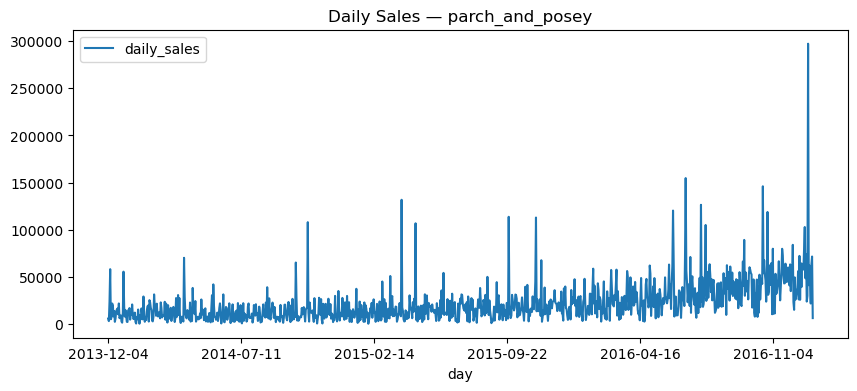

In [45]:
daily_sales = pd.read_sql(
    "SELECT DATE(occurred_at) AS day, SUM(total_amt_usd) AS daily_sales FROM orders GROUP BY day ORDER BY day",
    sqlite_conn,
)
daily_sales.plot(x="day", y="daily_sales", figsize=(10, 4), title="Daily Sales — parch_and_posey")

**Business question:** compare total revenue across regions for the quarterly business review.

<Axes: title={'center': 'Total Revenue by Region'}, xlabel='region'>

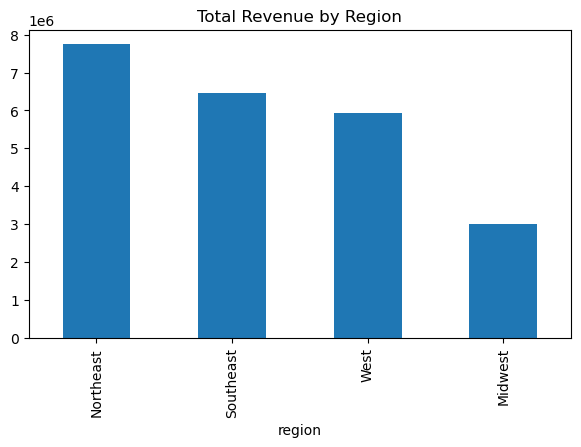

In [46]:
region_revenue = pd.read_sql(
    "SELECT r.name AS region, SUM(o.total_amt_usd) AS total_revenue "
    "FROM orders o JOIN accounts a ON o.account_id = a.id "
    "JOIN sales_reps s ON a.sales_rep_id = s.id "
    "JOIN region r ON s.region_id = r.id "
    "GROUP BY r.name ORDER BY total_revenue DESC",
    sqlite_conn,
)
region_revenue.plot(
    x="region", y="total_revenue", kind="bar", figsize=(7, 4),
    title="Total Revenue by Region", legend=False,
)

**Business question:** marketing wants the channel mix for a campaign review — which channels drive the most web traffic, at a glance.

<Axes: title={'center': 'Web Events by Channel'}>

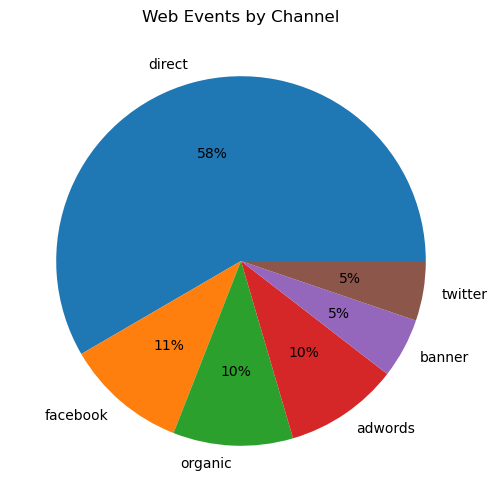

In [47]:
channel_events = pd.read_sql("SELECT channel FROM web_events", sqlite_conn)
channel_events["channel"].value_counts().plot(
    kind="pie", figsize=(6, 6), autopct="%1.0f%%", ylabel="",
    title="Web Events by Channel",
)

Three chart types, three real asks — a line for a trend over time, a bar for comparing categories, a pie for a proportional split. Same idea applies to virtually anything from the sweep above: get a DataFrame, call `.plot()`, pick the shape that fits the question.

## Section 5 — Passing parameters safely

Every query so far has had its filter values hardcoded. Real code usually takes that value from somewhere else — a form field, a function argument, another system — and the way you get it into the query matters, on any engine.

**Business question:** build a small function, `orders_for_account(account_id)`, that a dashboard could call with whatever account a user picks.

**The wrong way — an f-string:**

In [48]:
def orders_for_account_UNSAFE(account_id):
    query = f"SELECT id, occurred_at, total_amt_usd FROM orders WHERE account_id = {account_id}"
    return pd.read_sql(query, sqlite_conn)

orders_for_account_UNSAFE(1001).head()

,id,occurred_at,total_amt_usd
0,1,2015-10-06 17:31:14,973.43
1,2,2015-11-05 03:34:33,1718.03
2,3,2015-12-04 04:21:55,776.18
3,4,2016-01-02 01:18:24,958.24
4,5,2016-02-01 19:27:27,983.49


That works — until `account_id` isn't a clean integer. Anything that reaches this function gets pasted directly into the SQL string:

In [49]:
malicious_input = "1001 OR 1=1"
orders_for_account_UNSAFE(malicious_input)

,id,occurred_at,total_amt_usd
0,1,2015-10-06 17:31:14,973.43
1,2,2015-11-05 03:34:33,1718.03
2,3,2015-12-04 04:21:55,776.18
3,4,2016-01-02 01:18:24,958.24
4,5,2016-02-01 19:27:27,983.49
...,...,...,...
6907,6908,2016-06-29 04:03:39,2024.48
6908,6909,2016-07-29 19:58:32,1486.06
6909,6910,2016-08-27 00:58:11,1449.74
6910,6911,2016-11-22 06:52:22,1473.92


That returns **every order in the table**, not just account 1001's — the classic SQL injection pattern. The value was never meant to be SQL, but string-formatting it into the query let it become SQL.

**The right way — a bound parameter:**

In [50]:
def orders_for_account(account_id):
    query = "SELECT id, occurred_at, total_amt_usd FROM orders WHERE account_id = :acct_id"
    return pd.read_sql(query, sqlite_conn, params={"acct_id": account_id})

orders_for_account(1001).head()

,id,occurred_at,total_amt_usd
0,1,2015-10-06 17:31:14,973.43
1,2,2015-11-05 03:34:33,1718.03
2,3,2015-12-04 04:21:55,776.18
3,4,2016-01-02 01:18:24,958.24
4,5,2016-02-01 19:27:27,983.49


In [51]:
malicious_input = "1001 OR 1=1"
orders_for_account(malicious_input)

,id,occurred_at,total_amt_usd


That returns **zero rows**, not the malicious result — but notice it's a different kind of "safe" than MySQL's. Back in `day05_python_mysql.ipynb`, MySQL coerced the same string down to the leading number (`1001`) and returned the normal, correct rows for that account. SQLite is stricter: a text value never matches an integer column unless it's a clean number, so the malicious string just matches nothing. Both outcomes are equally safe — the value never got a chance to be parsed as SQL either way — they just fail differently, which is itself worth knowing before you assume one engine's error-handling behavior applies to the other.

`:acct_id` is a **placeholder**, not a slot for pasted text — the driver sends the query and the value to the database as two separate things, so the value is never parsed as SQL, no matter what it contains. This is the single most important habit in this notebook: **never build a query string with f-strings/`.format()`/`%`-formatting using a value that came from outside your own code.** Always use a placeholder (`:name`) and pass the value separately — no SQLAlchemy needed for this either, plain `sqlite3` supports named parameters natively, which is why the stored-procedure-equivalent function above already used `params={"acct_id": account_id}`.

## Section 6 — MySQL vs SQLite: what actually differs

That sweep only needed to change syntax twice — date formatting and `LAG`'s date input. The full list of what's actually different:

| Need | MySQL | SQLite |
|---|---|---|
| Format a date | `DATE_FORMAT(col, '%Y-%m')` | `STRFTIME('%Y-%m', col)` |
| Year part of a date | `YEAR(col)` | `STRFTIME('%Y', col)` |
| Date difference | `DATEDIFF(d1, d2)` | no `DATEDIFF` — `JULIANDAY(d1) - JULIANDAY(d2)` |
| Concatenate strings | `CONCAT(a, b)` | `a \|\| b` (also `CONCAT` on SQLite 3.44+) |
| Auto-increment PK | `AUTO_INCREMENT` | `AUTOINCREMENT` |
| Stored procedures | `CREATE PROCEDURE` | not supported at all |

Everything else from the sweep above — JOINs, CASE, string functions, subqueries, CTEs, temp tables, views, and every window function (`RANK`/`DENSE_RANK`/`ROW_NUMBER`/`LAG`/`LEAD`) — ran completely unchanged.

## Recap & what's next

This closes the core curriculum. Days 06-09 apply everything from Days 01-05 — filtering, JOINs, CASE, string functions, subqueries, CTEs, window functions — against real SQLite datasets (NBA, European Soccer, FitBit, World Development Indicators), with far less hand-holding. They'll connect the same way Section 3's Option 2 did here: a bare `%sql sqlite:///...` connection string, no SQLAlchemy required.